# 075: HP Alphabet Sweep — AUC Benchmark

Compares all named HP alphabets (thomas_dill, kyte_doolittle, thomas_dill_no_c, lehninger_plus_c, pbotc_1st_ed, shuffled_control) and 10 seeded shuffled controls across k-sizes 20–40. Computes family/superfamily/fold AUC and FAM AUC lift over FoldSeek.

**Outputs:** `auc_sweep_bonf_jaccard.parquet` (cached), `lift_sweep_bonf_jaccard.parquet` (cached)

**Next:** see 076 for per-class sensitivity & FoldSeek comparison.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy.stats import chi2_contingency

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS, TEA_DIR, SCOPE_CLASS_DESCRIPTIONS,
    load_baselines, add_composite_scores_scope, recompute_bonferroni,
    eval_tsv_to_rocx, rocx_restrict, sensitivity_stats,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
SWEEP_DIR  = Path.home() / 'data/scope/results-hp-alphabet-sweep'
FIG_PREFIX = '../figures/075'
Path('../figures').mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Alphabet definitions — alphabetical order; shuffled controls last (grey)
# ---------------------------------------------------------------------------
NAMED_LABELS = sorted([
    'hp_kyte_doolittle',
    'hp_lehninger_plus_c',
    'hp_pbotc_1st_ed',
    'hp_thomas_dill',
    'hp_thomas_dill_no_c',
])
SEED_LABELS = [f'hp_shuffled_control_{i}' for i in range(1, 11)]
ALL_LABELS  = NAMED_LABELS + SEED_LABELS

KSIZES = list(range(20, 41))   # pipeline ran k=20–40

BONF_THRESHOLD = 0.05

# SCOPe40 reference counts
N_SCOPE40_SINGLE = 14_873  # SCOPe 2.08 single-domain (class e multidomain excluded)
N_FOLDSEEK_SCOPE = 11_211  # FoldSeek paper benchmark (SCOPe 2.01)
NQUERY_MIN = round(N_SCOPE40_SINGLE / 100)  # 1% ≈ 149

# Designated best — thomas_dill k=26 (final)
BEST_LABEL = 'hp_thomas_dill'
BEST_K     = 26

# tab10 — one color per named alphabet (alphabetical), shuffled controls stay grey
_TAB10 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
NAMED_COLORS = {label: _TAB10[i] for i, label in enumerate(NAMED_LABELS)}

print('SWEEP_DIR:', SWEEP_DIR)
print('N alphabets:', len(ALL_LABELS))
print('K-sizes:', KSIZES[0], '–', KSIZES[-1])
print(f'NQUERY_MIN (1% of {N_SCOPE40_SINGLE:,}): {NQUERY_MIN}')
print(f'Best: {BEST_LABEL}  k={BEST_K}')
print('Colors:', {k.replace('hp_', ''): v for k, v in NAMED_COLORS.items()})

SWEEP_DIR: /Users/olga/data/scope/results-hp-alphabet-sweep
N alphabets: 15
K-sizes: 20 – 40
NQUERY_MIN (1% of 14,873): 149
Best: hp_thomas_dill  k=26
Colors: {'kyte_doolittle': '#1f77b4', 'lehninger_plus_c': '#ff7f0e', 'pbotc_1st_ed': '#2ca02c', 'thomas_dill': '#d62728', 'thomas_dill_no_c': '#9467bd'}


## Alphabet reference

| Alphabet | H residues | P residues | H count | P count | Notes |
|---|---|---|---|---|---|
| `hp_lehninger` *(old pipeline)* | AFGILMPVWY | CDEHKNQRST | 10 | 10 | **Original alphabet used in notebooks 059–069.** C is polar. Peaks at k=31 (FAM AUC=0.968, n=31 queries at Bonferroni<0.05). Results loaded from `results-scope-pvalue-benchmark/`. |
| `hp_lehninger_plus_c` | ACFGILMPVWY | DEHKNQRST | **11** | 9 | Lehninger + C moved to H. Best family AUC in this sweep at n≥150. |
| `hp_pbotc_1st_ed` | ACFILMPVWY | DEGHKNQRST | 10 | 10 | PBotC 1st ed. Also 10/10 but G is polar and C is hydrophobic. |
| `hp_thomas_dill` | ACFILMVWY | DEGHKNPQRST | 9 | 11 | Thomas & Dill 1996. Best overall FAM AUC in this sweep. |
| `hp_thomas_dill_no_c` | AFILMVWY | CDEGHKNPQRST | 8 | 12 | TD variant with C polar. Tests effect of C placement vs hp_thomas_dill. |
| `hp_kyte_doolittle` | ACFILMV | DEGHKNPQRSTWY | 7 | 13 | Most restrictive (hydropathy > 0 only). W, Y are polar. |
| `hp_shuffled_control` | *(random 10)* | *(random 10)* | 10 | 10 | Shuffled baseline. Named controls not in pipeline; seeded controls (1–10) are. |

**Why the original alphabet is included:** The original `hp_lehninger` was used in notebooks 059–069 where it found ~17 proteins uniquely (enriched for SCOP class c) that FoldSeek missed, at *raw* (unfiltered) level. Here it is compared at the same Bonferroni<0.05 threshold used for the new alphabets. Its coverage is much lower (≤31 queries vs 100–250 for new alphabets) because its k-mer model produces fewer statistically significant hits.

**The class-c unique detections** from notebooks 059–069 are not an artifact. Without Bonferroni filter, all 17 proteins are also found by the current sweep alphabets. See section 9 for details.

## 1. Data availability check

In [3]:
def eval_path(label: str, k: int) -> Path:
    gz = SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv.gz'
    return gz if gz.exists() else SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv'


def has_data(label: str, k: int) -> bool:
    p = eval_path(label, k)
    return p.exists() and p.stat().st_size > 0


available = {(lbl, k): has_data(lbl, k) for lbl in ALL_LABELS for k in KSIZES}
n_avail   = sum(available.values())
n_total   = len(available)

print(f'Available eval files: {n_avail} / {n_total}')
if n_avail == 0:
    print()
    print('⚠️  No eval files have data yet.')
    print('   The pipeline ran but kmerseek search wrote 0 rows to its output CSV.')
    print('   Check the search logs in SWEEP_DIR for details.')
    print('   Re-run the pipeline after fixing the kmerseek search output bug.')
    print()
    # Show example log to confirm matches were found
    example_log = SWEEP_DIR / 'scope40.hp_thomas_dill.k25.search.log'
    if example_log.exists():
        print(f'Example log ({example_log.name}):')
        for line in example_log.read_text().splitlines()[-8:]:
            print(' ', line)
else:
    by_label = {lbl: sum(available[(lbl, k)] for k in KSIZES) for lbl in ALL_LABELS}
    for lbl, n in sorted(by_label.items(), key=lambda x: -x[1]):
        print(f'  {lbl:<35s}: {n}/{len(KSIZES)} k-sizes')

Available eval files: 315 / 315
  hp_kyte_doolittle                  : 21/21 k-sizes
  hp_lehninger_plus_c                : 21/21 k-sizes
  hp_pbotc_1st_ed                    : 21/21 k-sizes
  hp_thomas_dill                     : 21/21 k-sizes
  hp_thomas_dill_no_c                : 21/21 k-sizes
  hp_shuffled_control_1              : 21/21 k-sizes
  hp_shuffled_control_2              : 21/21 k-sizes
  hp_shuffled_control_3              : 21/21 k-sizes
  hp_shuffled_control_4              : 21/21 k-sizes
  hp_shuffled_control_5              : 21/21 k-sizes
  hp_shuffled_control_6              : 21/21 k-sizes
  hp_shuffled_control_7              : 21/21 k-sizes
  hp_shuffled_control_8              : 21/21 k-sizes
  hp_shuffled_control_9              : 21/21 k-sizes
  hp_shuffled_control_10             : 21/21 k-sizes


## 2. Load baselines

In [4]:
foldseek, tea_all = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())

_, _, fs_fam  = sensitivity_stats(foldseek, 'FAM')
_, _, fs_sfam = sensitivity_stats(foldseek, 'SFAM')
_, _, fs_fold = sensitivity_stats(foldseek, 'FOLD')
_, _, tea_fam  = sensitivity_stats(tea_all,  'FAM')
_, _, tea_sfam = sensitivity_stats(tea_all,  'SFAM')
_, _, tea_fold = sensitivity_stats(tea_all,  'FOLD')

print(f'FoldSeek: {foldseek["NAME"].n_unique():,} queries  FAM={fs_fam:.4f}  SFAM={fs_sfam:.4f}  FOLD={fs_fold:.4f}')
print(f'TEA:      {tea_all["NAME"].n_unique():,} queries  FAM={tea_fam:.4f}  SFAM={tea_sfam:.4f}  FOLD={tea_fold:.4f}')
print(f'Benchmarkable query set: {len(ref_queries):,}')

FoldSeek: 5,713 queries  FAM=0.8169  SFAM=0.5743  FOLD=0.1017
TEA:      5,737 queries  FAM=0.8020  SFAM=0.5804  FOLD=0.0868
Benchmarkable query set: 5,713


In [5]:
# ---------------------------------------------------------------------------
# Load original hp_lehninger (old pipeline — results-scope-pvalue-benchmark)
# ---------------------------------------------------------------------------
OLD_HP_DIR   = Path.home() / 'data/scope/results-scope-pvalue-benchmark'
OLD_HP_COLOR = _TAB10[len(NAMED_LABELS)]   # tab10[5] = #8c564b (brown), after named alphabets
OLD_HP_LABEL = 'lehninger'

old_hp_rows = []
for k in range(28, 46):
    p = OLD_HP_DIR / f'scope_eval.hp.k{k}.parquet'
    if not p.exists():
        continue
    df = pl.read_parquet(p)
    if 'bonferroni_correct' not in df.columns:
        continue
    filt = df.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
    if filt.height == 0:
        continue
    rocx   = eval_tsv_to_rocx(filt, score_col='jaccard', ascending=False, exclude_gray_zone=True)
    rocx_r = rocx.filter(pl.col('NAME').is_in(ref_queries))
    if rocx_r.height == 0:
        continue
    _, _, fam_auc      = sensitivity_stats(rocx_r, 'FAM')
    _, _, sfam_auc     = sensitivity_stats(rocx_r, 'SFAM')
    _, _, fold_auc     = sensitivity_stats(rocx_r, 'FOLD')
    _, _, fam_auc_all  = sensitivity_stats(rocx,   'FAM')
    old_hp_rows.append(dict(
        ksize=k,
        n_queries_ref=rocx_r['NAME'].n_unique(),
        n_queries_all=rocx['NAME'].n_unique(),
        auc_fam_ref =round(fam_auc,     5),
        auc_sfam_ref=round(sfam_auc,    5),
        auc_fold_ref=round(fold_auc,    5),
        auc_fam_all =round(fam_auc_all, 5),
    ))

old_hp_auc_df = pl.DataFrame(old_hp_rows) if old_hp_rows else pl.DataFrame()
print(f'Original hp_lehninger: {len(old_hp_rows)} k-sizes with data (Bonferroni<{BONF_THRESHOLD})')
if old_hp_auc_df.height > 0:
    print(old_hp_auc_df.sort('ksize').select(['ksize', 'n_queries_ref', 'n_queries_all', 'auc_fam_ref', 'auc_fam_all']))

Original hp_lehninger: 8 k-sizes with data (Bonferroni<0.05)
shape: (8, 5)
┌───────┬───────────────┬───────────────┬─────────────┬─────────────┐
│ ksize ┆ n_queries_ref ┆ n_queries_all ┆ auc_fam_ref ┆ auc_fam_all │
│ ---   ┆ ---           ┆ ---           ┆ ---         ┆ ---         │
│ i64   ┆ i64           ┆ i64           ┆ f64         ┆ f64         │
╞═══════╪═══════════════╪═══════════════╪═════════════╪═════════════╡
│ 31    ┆ 31            ┆ 96            ┆ 0.96774     ┆ 0.98958     │
│ 32    ┆ 24            ┆ 74            ┆ 0.95833     ┆ 0.98649     │
│ 33    ┆ 19            ┆ 56            ┆ 0.94737     ┆ 0.98214     │
│ 34    ┆ 15            ┆ 47            ┆ 0.93333     ┆ 0.97872     │
│ 35    ┆ 13            ┆ 37            ┆ 0.92308     ┆ 0.97297     │
│ 36    ┆ 10            ┆ 31            ┆ 0.9         ┆ 0.96774     │
│ 37    ┆ 5             ┆ 19            ┆ 0.8         ┆ 0.94737     │
│ 38    ┆ 3             ┆ 15            ┆ 0.66667     ┆ 0.93333     │
└───────┴──────

## 3. AUC sweep (Bonferroni<0.05 + Jaccard, all alphabets × k-sizes)

In [6]:
def load_eval_alphabet(
    label: str, k: int, columns=None
) -> pl.DataFrame:
    """Load scope_eval file for a given alphabet label and k-size."""
    path = eval_path(label, k)
    if not path.exists():
        raise FileNotFoundError(f'Missing: {path}')
    if path.stat().st_size == 0:
        raise FileNotFoundError(f'Empty: {path}')
    df = pl.read_csv(path, separator='\t')
    if columns is not None:
        df = df.select([c for c in columns if c in df.columns])
    return df

In [7]:
CACHE_PATH = SWEEP_DIR / 'auc_sweep_bonf_jaccard.parquet'
FORCE_RECOMPUTE = False  # cache uses full ref_queries denominator (FoldSeek-compatible)

if not FORCE_RECOMPUTE and CACHE_PATH.exists():
    auc_df = pl.read_parquet(CACHE_PATH)
    print(f'Loaded cached AUC sweep: {len(auc_df):,} rows')
else:
    rows = []
    for label in ALL_LABELS:
        print(f'{label}:', end=' ', flush=True)
        for k in KSIZES:
            try:
                ev = load_eval_alphabet(label, k, columns=EVAL_USECOLS)
            except FileNotFoundError:
                print('_', end='', flush=True)
                continue
            ev = add_composite_scores_scope(ev)
            ev = recompute_bonferroni(ev)
            ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)

            rocx   = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                       exclude_gray_zone=True)
            # n_queries_ref = covered count (for NQUERY_MIN threshold)
            # rocx_r uses rocx_restrict so AUC denominator = all ref_queries
            # (missing queries get FAM=0, matching FoldSeek methodology)
            # rocx_restrict requires the 9 core TEA columns; strip extras first
            _core = [c for c in ['NAME','SCOP','FAM','SFAM','FOLD',
                                  'FP','FAMCNT','SFAMCNT','FOLDCNT']
                     if c in rocx.columns]
            rocx_r_cov = rocx.select(_core).filter(pl.col('NAME').is_in(ref_queries))
            rocx_r     = rocx_restrict(rocx.select(_core), ref_queries)

            def _aucs(r, level):
                return sensitivity_stats(r, level)[2]

            rows.append(dict(
                label=label, ksize=k,
                n_queries_all=rocx['NAME'].n_unique(),
                n_queries_ref=rocx_r_cov['NAME'].n_unique(),
                auc_fam_all =round(_aucs(rocx,   'FAM'),  5),
                auc_sfam_all=round(_aucs(rocx,   'SFAM'), 5),
                auc_fold_all=round(_aucs(rocx,   'FOLD'), 5),
                auc_fam_ref =round(_aucs(rocx_r, 'FAM'),  5),
                auc_sfam_ref=round(_aucs(rocx_r, 'SFAM'), 5),
                auc_fold_ref=round(_aucs(rocx_r, 'FOLD'), 5),
            ))
            print('.', end='', flush=True)
            del ev, ev_filt, rocx, rocx_r; gc.collect()
        print()

    if rows:
        auc_df = pl.DataFrame(rows)
        auc_df.write_parquet(CACHE_PATH)
        print(f'Saved {len(auc_df):,} rows → {CACHE_PATH.name}')
    else:
        print('No data available — auc_df is empty (pipeline results missing)')
        auc_df = pl.DataFrame(schema={
            'label': pl.Utf8, 'ksize': pl.Int64,
            'n_queries_all': pl.Int64, 'n_queries_ref': pl.Int64,
            'auc_fam_all': pl.Float64, 'auc_sfam_all': pl.Float64, 'auc_fold_all': pl.Float64,
            'auc_fam_ref': pl.Float64, 'auc_sfam_ref': pl.Float64, 'auc_fold_ref': pl.Float64,
        })

Loaded cached AUC sweep: 336 rows


## 4. Best k-sizes per alphabet

In [8]:
def best_ksize_for_label(auc_df, label, nquery_min=None, level_col='auc_fam_ref'):
    """Return best k-size row for a given alphabet and coverage threshold."""
    sub = auc_df.filter(pl.col('label') == label)
    if nquery_min is not None:
        sub = sub.filter(pl.col('n_queries_ref') >= nquery_min)
    if sub.height == 0:
        return None
    return sub.sort(level_col, descending=True).row(0, named=True)


if auc_df.height > 0:
    PCT_THRESHOLDS = [0.01, 0.02, 0.03, 0.04, 0.05]
    pct_nqmin = {p: round(N_SCOPE40_SINGLE * p) for p in PCT_THRESHOLDS}

    print(f'=== Best k-sizes per alphabet (Bonferroni<{BONF_THRESHOLD} + Jaccard, excl. gray zone) ===')
    print(f'Coverage thresholds = % of {N_SCOPE40_SINGLE:,} single-domain SCOPe40 proteins (class e excluded)\n')

    pct_hdrs = ''.join(f'{f"{p*100:.0f}%(≥{n})":>12}' for p, n in pct_nqmin.items())
    header = f'{"Alphabet":<35} {"Overall":>10}' + pct_hdrs
    print(header); print('-' * len(header))

    best_ks = {}
    for label in ALL_LABELS:
        best_overall = best_ksize_for_label(auc_df, label)
        pct_bests    = {p: best_ksize_for_label(auc_df, label, nquery_min=n)
                        for p, n in pct_nqmin.items()}

        def fmt(row):
            if row is None: return '       —    '
            return f'k={row["ksize"]:2d}(n={row["n_queries_ref"]:3d})'

        row_str = f'{label:<35} {fmt(best_overall):>10}'
        row_str += ''.join(f'{fmt(pct_bests[p]):>12}' for p in PCT_THRESHOLDS)
        print(row_str)
        best_ks[label] = best_overall
else:
    print('No data — skipping best-k summary.')
    best_ks = {lbl: None for lbl in ALL_LABELS}


=== Best k-sizes per alphabet (Bonferroni<0.05 + Jaccard, excl. gray zone) ===
Coverage thresholds = % of 14,873 single-domain SCOPe40 proteins (class e excluded)

Alphabet                               Overall    1%(≥149)    2%(≥297)    3%(≥446)    4%(≥595)    5%(≥744)
----------------------------------------------------------------------------------------------------------
hp_kyte_doolittle                   k=20(n=707) k=20(n=707) k=20(n=707) k=20(n=707) k=20(n=707)       —    
hp_lehninger_plus_c                 k=20(n=520) k=20(n=520) k=20(n=520) k=20(n=520)       —           —    
hp_pbotc_1st_ed                     k=20(n=693) k=20(n=693) k=20(n=693) k=20(n=693) k=20(n=693)       —    
hp_thomas_dill                      k=20(n=843) k=20(n=843) k=20(n=843) k=20(n=843) k=20(n=843) k=20(n=843)
hp_thomas_dill_no_c                 k=20(n=787) k=20(n=787) k=20(n=787) k=20(n=787) k=20(n=787) k=20(n=787)
hp_shuffled_control_1               k=20(n= 56)       —           —           —   

## 5. AUC vs k-size — all alphabets, FoldSeek-shared queries

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_32192/1803769894.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.94])


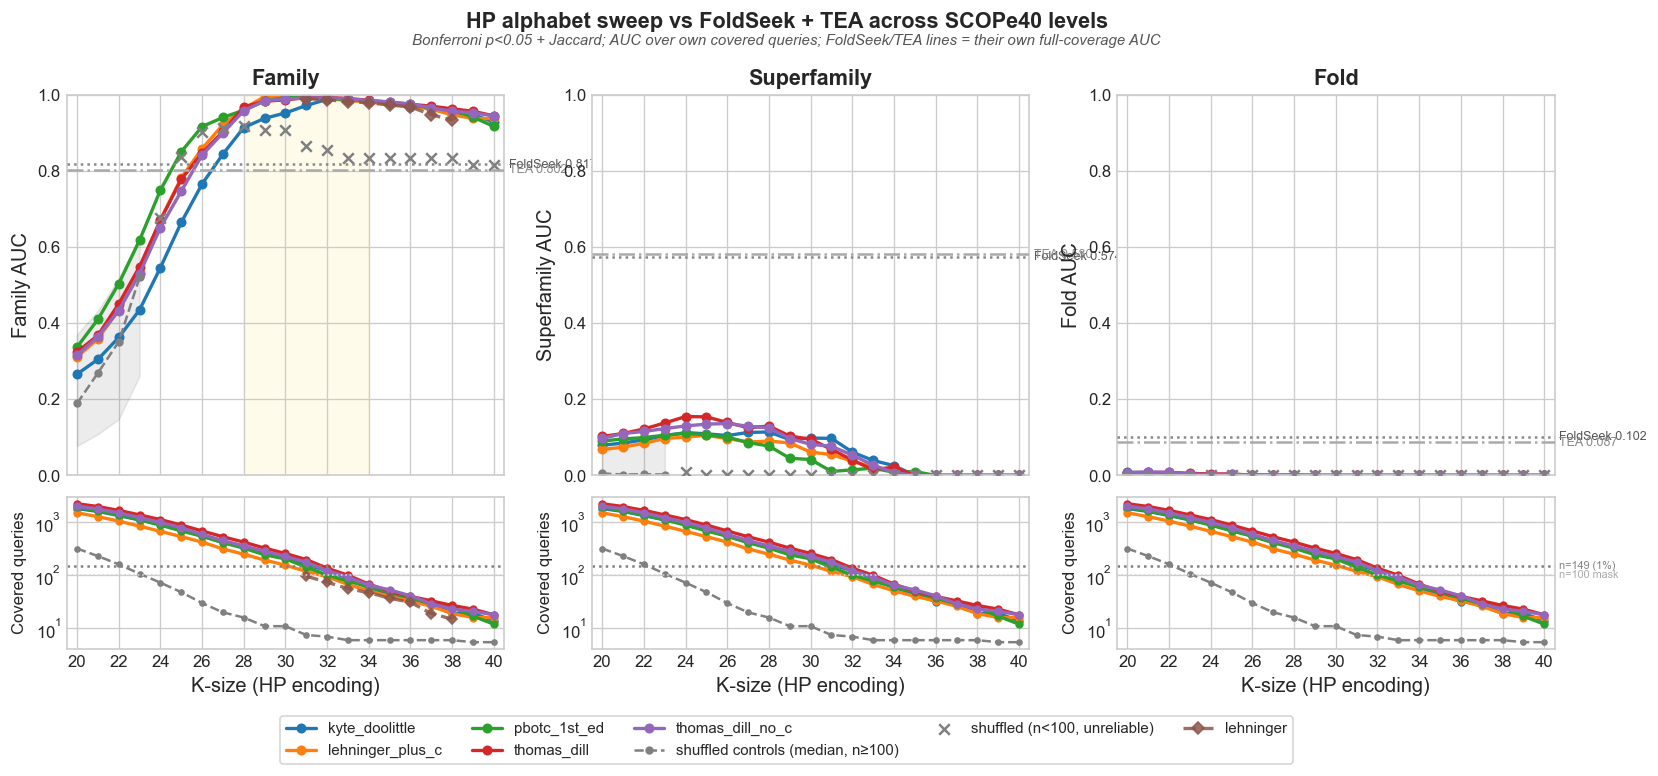

In [9]:
if auc_df.height == 0:
    print('No data to plot.')
else:
    LEVEL_SPECS = [
        ('Family',      'auc_fam_ref',  'auc_fam_all',  fs_fam,  tea_fam),
        ('Superfamily', 'auc_sfam_ref', 'auc_sfam_all', fs_sfam, tea_sfam),
        ('Fold',        'auc_fold_ref', 'auc_fold_all', fs_fold, tea_fold),
    ]

    N_SHUFFLE_MIN = 100
    XLIM = (KSIZES[0] - 0.5, KSIZES[-1] + 0.5)

    fig, axes = plt.subplots(2, 3, figsize=(16, 6),
                              gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})

    for col, (level_name, auc_ref_col, auc_all_col, fs_auc, tea_auc) in enumerate(LEVEL_SPECS):
        ax_auc, ax_nq = axes[0, col], axes[1, col]

        ax_auc.axhline(fs_auc,  color='#888', ls=':',  lw=1.5, zorder=4)
        ax_auc.axhline(tea_auc, color='#aaa', ls='-.', lw=1.5, zorder=4)
        ax_auc.text(1.01, fs_auc,  f'FoldSeek {fs_auc:.3f}',
                    transform=ax_auc.get_yaxis_transform(),
                    va='center', ha='left', fontsize=7.5, color='#555', clip_on=False)
        ax_auc.text(1.01, tea_auc, f'TEA {tea_auc:.3f}',
                    transform=ax_auc.get_yaxis_transform(),
                    va='center', ha='left', fontsize=7.5, color='#888', clip_on=False)

        if col == 0:
            ax_auc.axvspan(28, 34, alpha=0.08, color='gold', zorder=0, label='_nolegend_')

        for label in NAMED_LABELS:
            sub = auc_df.filter(pl.col('label') == label).sort('ksize')
            if sub.height == 0:
                continue
            color = NAMED_COLORS[label]
            lbl = label.replace('hp_', '') if col == 0 else '_nolegend_'
            # use auc_all_col (per-covered-query AUC) — consistent with hp_lehninger
            ax_auc.plot(sub['ksize'].to_numpy(), sub[auc_all_col].to_numpy(),
                        'o-', color=color, lw=2, ms=5, label=lbl)
            ax_nq.plot(sub['ksize'].to_numpy(), sub['n_queries_all'].to_numpy(),
                       'o-', color=color, lw=2, ms=4)

        seed_sub = auc_df.filter(pl.col('label').is_in(SEED_LABELS))
        if seed_sub.height > 0:
            seed_grp = (seed_sub.group_by('ksize')
                        .agg([
                            pl.col(auc_all_col).median().alias('med'),
                            pl.col(auc_all_col).min().alias('lo'),
                            pl.col(auc_all_col).max().alias('hi'),
                            pl.col('n_queries_all').median().alias('nq'),
                        ])
                        .sort('ksize'))
            seed_reliable   = seed_grp.filter(pl.col('nq') >= N_SHUFFLE_MIN)
            seed_unreliable = seed_grp.filter(pl.col('nq') < N_SHUFFLE_MIN)
            if seed_reliable.height > 0:
                ks_r = seed_reliable['ksize'].to_numpy()
                lbl_sc = f'shuffled controls (median, n≥{N_SHUFFLE_MIN})' if col == 0 else '_nolegend_'
                ax_auc.plot(ks_r, seed_reliable['med'].to_numpy(), 'o--', color='grey', lw=1.5, ms=4,
                            label=lbl_sc)
                ax_auc.fill_between(ks_r, seed_reliable['lo'].to_numpy(), seed_reliable['hi'].to_numpy(),
                                    color='grey', alpha=0.15)
            if seed_unreliable.height > 0:
                ks_u = seed_unreliable['ksize'].to_numpy()
                lbl_u = f'shuffled (n<{N_SHUFFLE_MIN}, unreliable)' if col == 0 else '_nolegend_'
                ax_auc.scatter(ks_u, seed_unreliable['med'].to_numpy(),
                               marker='x', color='grey', s=40, linewidths=1.5, zorder=3,
                               label=lbl_u)
            ax_nq.plot(seed_grp['ksize'].to_numpy(), seed_grp['nq'].to_numpy(),
                       'o--', color='grey', lw=1.5, ms=3)

        if 'old_hp_auc_df' in dir() and old_hp_auc_df.height > 0 and auc_all_col in old_hp_auc_df.columns:
            sub_hp = old_hp_auc_df.sort('ksize')
            lbl_old = OLD_HP_LABEL if col == 0 else '_nolegend_'
            ax_auc.plot(sub_hp['ksize'].to_numpy(), sub_hp[auc_all_col].to_numpy(),
                        'D--', color=OLD_HP_COLOR, lw=2, ms=5, alpha=0.85, label=lbl_old)
            ax_nq.plot(sub_hp['ksize'].to_numpy(), sub_hp['n_queries_all'].to_numpy(),
                       'D--', color=OLD_HP_COLOR, lw=2, ms=4, alpha=0.85)

        ax_nq.axhline(NQUERY_MIN,    color='grey',      ls=':', lw=1.5)
        ax_nq.axhline(N_SHUFFLE_MIN, color='lightgrey', ls=':', lw=1)
        if col == 2:
            ax_nq.text(1.01, NQUERY_MIN,    f'n={NQUERY_MIN} (1%)',
                       transform=ax_nq.get_yaxis_transform(),
                       va='center', ha='left', fontsize=6.5, color='grey',  clip_on=False)
            ax_nq.text(1.01, N_SHUFFLE_MIN, f'n={N_SHUFFLE_MIN} mask',
                       transform=ax_nq.get_yaxis_transform(),
                       va='center', ha='left', fontsize=6.5, color='#aaa', clip_on=False)

        ax_auc.set_ylabel(f'{level_name} AUC', fontsize=12)
        ax_auc.set_title(level_name, fontsize=13, fontweight='bold')
        ax_auc.set_xlim(*XLIM)
        ax_auc.set_ylim(0, 1)
        ax_auc.set_xticklabels([])
        ax_auc.xaxis.set_major_locator(plt.MultipleLocator(2))
        ax_nq.set_xlabel('K-size (HP encoding)', fontsize=12)
        ax_nq.set_ylabel('Covered queries', fontsize=10)
        ax_nq.set_xlim(*XLIM)
        ax_nq.set_yscale('log')
        ax_nq.xaxis.set_major_locator(plt.MultipleLocator(2))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, -0.06), fontsize=9, frameon=True)
    fig.text(0.5, 0.995, 'HP alphabet sweep vs FoldSeek + TEA across SCOPe40 levels',
             ha='center', va='top', fontsize=13, fontweight='bold', transform=fig.transFigure)
    fig.text(0.5, 0.965,
             f'Bonferroni p<{BONF_THRESHOLD} + Jaccard; AUC over own covered queries; '
             f'FoldSeek/TEA lines = their own full-coverage AUC',
             ha='center', va='top', fontsize=9, color='#555', style='italic',
             transform=fig.transFigure)
    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    plt.savefig(f'{FIG_PREFIX}_auc_vs_ksize_ref.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. AUC vs k-size — over own covered queries

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_32192/1336620374.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.07, 1, 0.95])


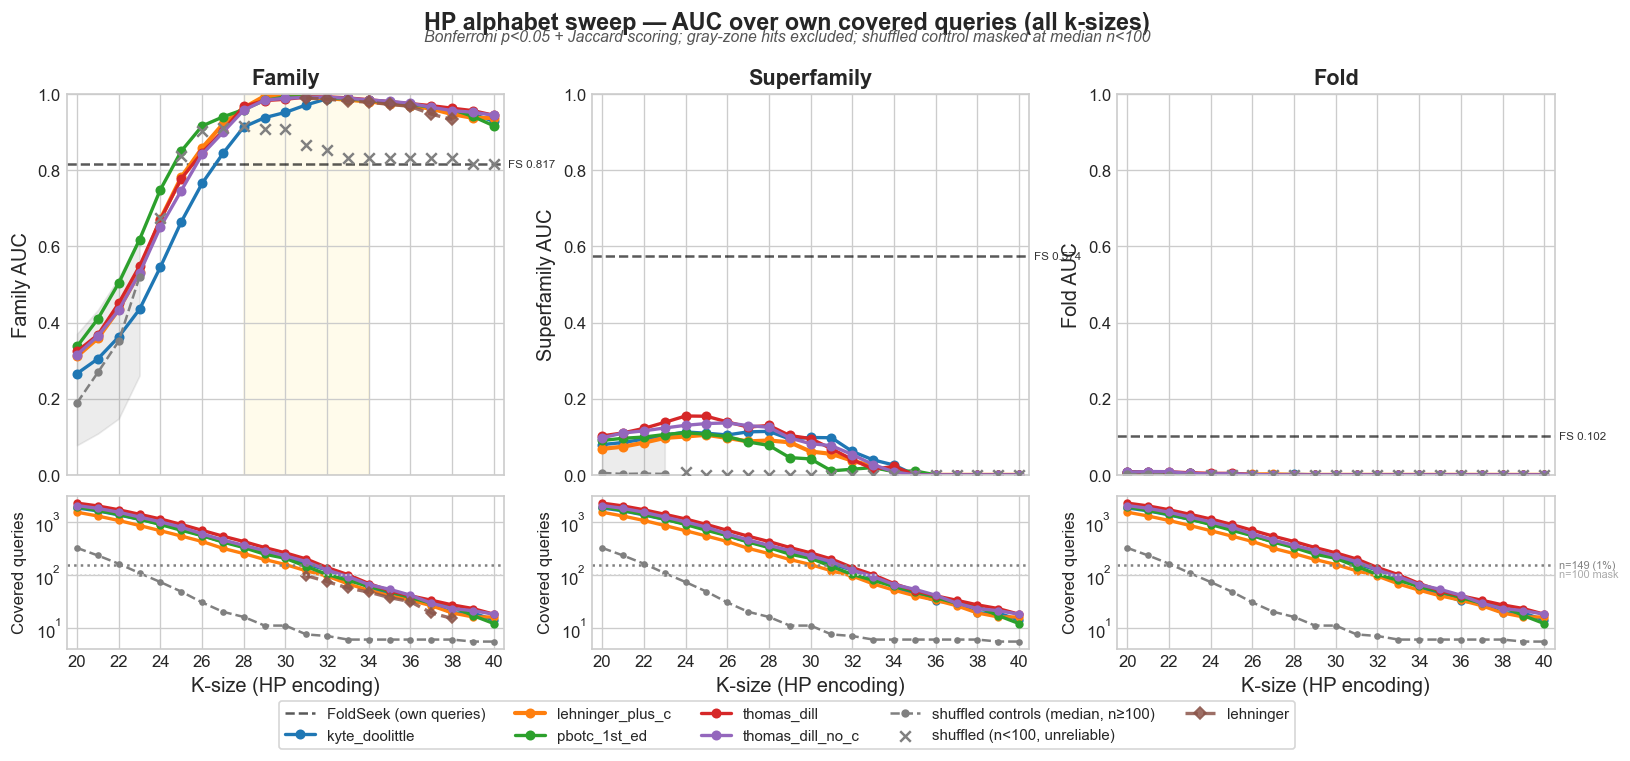

In [10]:
if auc_df.height == 0:
    print('No data to plot.')
else:
    N_SHUFFLE_MIN = 100  # same threshold as auc-vs-ksize-ref
    XLIM = (KSIZES[0] - 0.5, KSIZES[-1] + 0.5)

    fig, axes = plt.subplots(2, 3, figsize=(16, 6),
                              gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})

    for col, (level_name, auc_ref_col, auc_all_col, fs_auc, tea_auc) in enumerate(LEVEL_SPECS):
        ax_auc, ax_nq = axes[0, col], axes[1, col]

        # Optimal-k band on Family panel
        if col == 0:
            ax_auc.axvspan(28, 34, alpha=0.08, color='gold', zorder=0, label='_nolegend_')

        # FoldSeek reference (note: different query denominator than KmerSeek)
        _fs_lbl = 'FoldSeek (own queries)' if col == 0 else '_nolegend_'
        ax_auc.axhline(fs_auc, color='black', ls='--', lw=1.5, alpha=0.65, label=_fs_lbl)
        ax_auc.text(XLIM[1] + 0.2, fs_auc,
                    f'FS {fs_auc:.3f}', va='center', ha='left',
                    fontsize=7, color='#333', clip_on=False)

        for label in NAMED_LABELS:
            sub = auc_df.filter(pl.col('label') == label).sort('ksize')
            if sub.height == 0:
                continue
            color = NAMED_COLORS[label]
            lw = 2.5 if label == 'hp_lehninger_plus_c' else 2
            lbl = label.replace('hp_', '') if col == 0 else '_nolegend_'
            ax_auc.plot(sub['ksize'].to_numpy(), sub[auc_all_col].to_numpy(),
                        'o-', color=color, lw=lw, ms=5, label=lbl)
            ax_nq.plot(sub['ksize'].to_numpy(), sub['n_queries_all'].to_numpy(),
                       'o-', color=color, lw=2, ms=4)

        seed_sub = auc_df.filter(pl.col('label').is_in(SEED_LABELS))
        if seed_sub.height > 0:
            seed_grp = (seed_sub.group_by('ksize')
                        .agg([
                            pl.col(auc_all_col).median().alias('med'),
                            pl.col(auc_all_col).min().alias('lo'),
                            pl.col(auc_all_col).max().alias('hi'),
                            pl.col('n_queries_all').median().alias('nq'),
                        ])
                        .sort('ksize'))
            seed_reliable   = seed_grp.filter(pl.col('nq') >= N_SHUFFLE_MIN)
            seed_unreliable = seed_grp.filter(pl.col('nq') < N_SHUFFLE_MIN)
            if seed_reliable.height > 0:
                ks_r = seed_reliable['ksize'].to_numpy()
                lbl_sc = f'shuffled controls (median, n≥{N_SHUFFLE_MIN})' if col == 0 else '_nolegend_'
                ax_auc.plot(ks_r, seed_reliable['med'].to_numpy(), 'o--', color='grey', lw=1.5, ms=4,
                            label=lbl_sc)
                ax_auc.fill_between(ks_r, seed_reliable['lo'].to_numpy(), seed_reliable['hi'].to_numpy(),
                                    color='grey', alpha=0.15)
            if seed_unreliable.height > 0:
                ks_u = seed_unreliable['ksize'].to_numpy()
                lbl_u = f'shuffled (n<{N_SHUFFLE_MIN}, unreliable)' if col == 0 else '_nolegend_'
                ax_auc.scatter(ks_u, seed_unreliable['med'].to_numpy(),
                               marker='x', color='grey', s=40, linewidths=1.5, zorder=3,
                               label=lbl_u)
            ax_nq.plot(seed_grp['ksize'].to_numpy(), seed_grp['nq'].to_numpy(),
                       'o--', color='grey', lw=1.5, ms=3)

        if 'old_hp_auc_df' in dir() and old_hp_auc_df.height > 0 and auc_all_col in old_hp_auc_df.columns:
            sub_hp = old_hp_auc_df.sort('ksize')
            lbl_old = OLD_HP_LABEL if col == 0 else '_nolegend_'
            ax_auc.plot(sub_hp['ksize'].to_numpy(), sub_hp[auc_all_col].to_numpy(),
                        'D--', color=OLD_HP_COLOR, lw=2, ms=5, alpha=0.85, label=lbl_old)
            ax_nq.plot(sub_hp['ksize'].to_numpy(), sub_hp['n_queries_all'].to_numpy(),
                       'D--', color=OLD_HP_COLOR, lw=2, ms=4, alpha=0.85)

        ax_nq.axhline(NQUERY_MIN,    color='grey',      ls=':', lw=1.5)
        ax_nq.axhline(N_SHUFFLE_MIN, color='lightgrey', ls=':', lw=1)
        if col == 2:
            ax_nq.text(1.01, NQUERY_MIN,    f'n={NQUERY_MIN} (1%)',
                       transform=ax_nq.get_yaxis_transform(),
                       va='center', ha='left', fontsize=6.5, color='grey',  clip_on=False)
            ax_nq.text(1.01, N_SHUFFLE_MIN, f'n={N_SHUFFLE_MIN} mask',
                       transform=ax_nq.get_yaxis_transform(),
                       va='center', ha='left', fontsize=6.5, color='#aaa', clip_on=False)

        ax_auc.set_ylabel(f'{level_name} AUC', fontsize=12)
        ax_auc.set_title(level_name, fontsize=13, fontweight='bold')
        ax_auc.set_xlim(*XLIM)
        ax_auc.set_ylim(0, 1)
        ax_auc.set_xticklabels([])
        ax_auc.xaxis.set_major_locator(plt.MultipleLocator(2))
        ax_nq.set_xlabel('K-size (HP encoding)', fontsize=12)
        ax_nq.set_ylabel('Covered queries', fontsize=10)
        ax_nq.set_xlim(*XLIM)
        ax_nq.set_yscale('log')
        ax_nq.xaxis.set_major_locator(plt.MultipleLocator(2))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, -0.04), fontsize=9, frameon=True)
    fig.text(0.5, 0.995, 'HP alphabet sweep — AUC over own covered queries (all k-sizes)',
             ha='center', va='top', fontsize=14, fontweight='bold', transform=fig.transFigure)
    fig.text(0.5, 0.970,
             f'Bonferroni p<{BONF_THRESHOLD} + Jaccard scoring; gray-zone hits excluded; '
             f'shuffled control masked at median n<{N_SHUFFLE_MIN}',
             ha='center', va='top', fontsize=9.5, color='#555', style='italic',
             transform=fig.transFigure)
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.savefig(f'{FIG_PREFIX}_auc_vs_ksize_own.png', dpi=150, bbox_inches='tight')
    plt.show()

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_32192/2579926830.py:161: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_32192/2579926830.py:162: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(f'{FIG_PREFIX}_coverage_vs_auc.png', dpi=150,
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


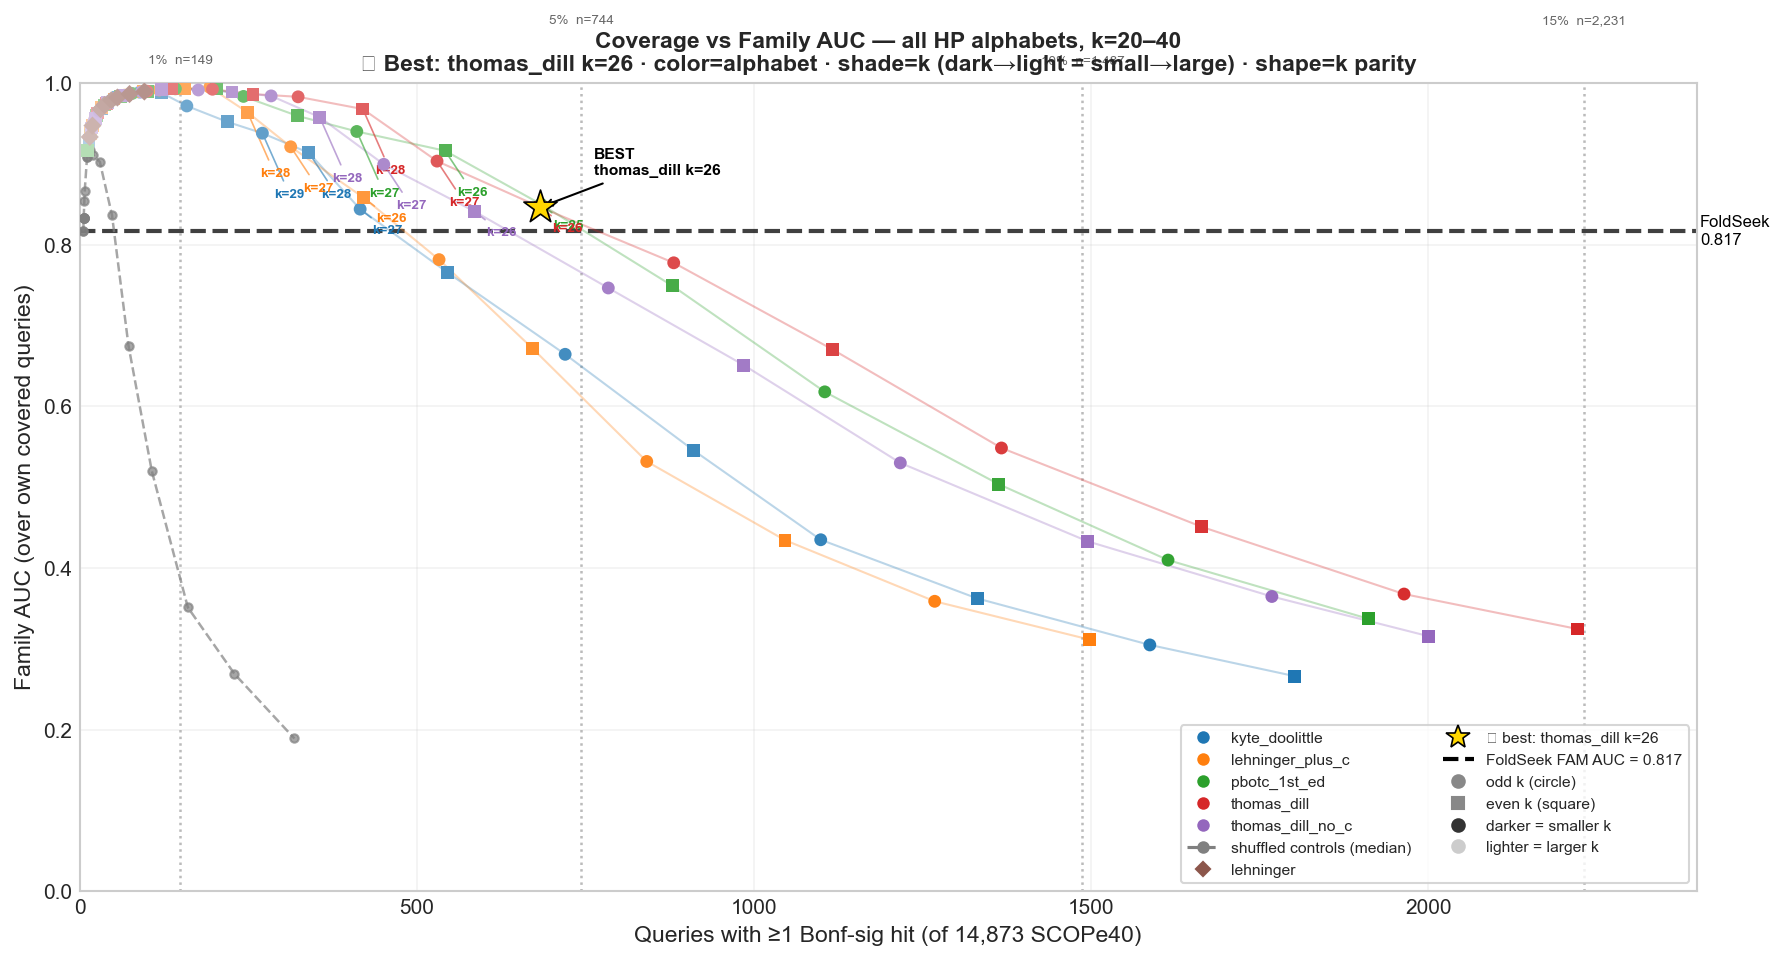

Saved: ../figures/075_coverage_vs_auc.png


In [11]:
if auc_df.height == 0:
    print('No data.')
else:
    import matplotlib.colors as mcolors
    import matplotlib.patheffects as pe
    from matplotlib.lines import Line2D

    N_SCOPE40  = N_SCOPE40_SINGLE
    PCT_LINES  = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25]
    K_MIN, K_MAX = KSIZES[0], KSIZES[-1]

    # k-size visual encoding: circle=odd k, square=even k; darker=smaller k
    def _kcolor(base_hex, k):
        """Blend base color toward white based on k position (larger k → lighter)."""
        k_norm = (k - K_MIN) / (K_MAX - K_MIN)
        base = mcolors.to_rgb(base_hex)
        return tuple(b + (1 - b) * k_norm * 0.65 for b in base)

    def _kmarker(k):
        return 's' if k % 2 == 0 else 'o'  # square=even, circle=odd

    fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')

    legend_proxies = []
    best_fs_pts = {}  # label → list of (k, x, y) that beat FoldSeek, sorted by k asc

    # ── Named alphabets ───────────────────────────────────────────────────────
    for label in NAMED_LABELS:
        sub = auc_df.filter(pl.col('label') == label).sort('n_queries_all')
        if sub.height == 0:
            continue
        color = NAMED_COLORS[label]
        xs = sub['n_queries_all'].to_numpy()
        ys = sub['auc_fam_all'].to_numpy()
        ks = sub['ksize'].to_numpy()
        lbl = label.replace('hp_', '')

        # Thin connecting line
        ax.plot(xs, ys, '-', color=color, lw=1.0, alpha=0.3, zorder=3)

        # Per-point: k-size gradient + even/odd marker
        for k, x, y in zip(ks, xs, ys):
            ax.scatter([x], [y], c=[_kcolor(color, k)], s=38,
                       marker=_kmarker(k), zorder=5, edgecolors='none')

        # Collect points that beat FoldSeek
        above = [(k, x, y) for k, x, y in zip(ks, xs, ys) if y > fs_fam]
        above.sort(key=lambda t: t[0])
        best_fs_pts[label] = (above, color)

        legend_proxies.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                   markersize=7, label=lbl)
        )

    # ── Shuffled controls ─────────────────────────────────────────────────────
    seed_sub = auc_df.filter(pl.col('label').is_in(SEED_LABELS))
    if seed_sub.height > 0:
        seed_grp = (seed_sub.group_by('ksize')
                    .agg([pl.col('n_queries_all').median().alias('nx'),
                          pl.col('auc_fam_all').median().alias('ay')])
                    .sort('nx'))
        ax.plot(seed_grp['nx'].to_numpy(), seed_grp['ay'].to_numpy(),
                'o--', color='grey', lw=1.2, ms=4, alpha=0.7, zorder=3)
        legend_proxies.append(
            Line2D([0], [0], marker='o', color='grey', linestyle='--',
                   markersize=5, label='shuffled controls (median)')
        )

    # ── hp_lehninger (old pipeline) ───────────────────────────────────────────
    if 'old_hp_auc_df' in dir() and old_hp_auc_df.height > 0 and 'n_queries_all' in old_hp_auc_df.columns:
        _oh = old_hp_auc_df.sort('n_queries_all')
        _oh_xs = _oh['n_queries_all'].to_numpy()
        _oh_ys = _oh['auc_fam_all'].to_numpy()
        _oh_ks = _oh['ksize'].to_numpy()
        ax.plot(_oh_xs, _oh_ys, '-', color=OLD_HP_COLOR, lw=1.0, alpha=0.3, zorder=3)
        for k, x, y in zip(_oh_ks, _oh_xs, _oh_ys):
            ax.scatter([x], [y], c=[_kcolor(OLD_HP_COLOR, k)], s=38,
                       marker='D', zorder=5, edgecolors='none')
        legend_proxies.append(
            Line2D([0], [0], marker='D', color='w', markerfacecolor=OLD_HP_COLOR,
                   markersize=7, label=OLD_HP_LABEL)
        )

    # ── Annotate 3 smallest k-sizes per alphabet that beat FoldSeek ──────────
    for label, (pts, color) in best_fs_pts.items():
        for i, (k, x, y) in enumerate(pts[:3]):
            dy = [0.03, 0.055, 0.08][i]
            ax.annotate(f'k={k}', xy=(x, y), xytext=(x + 18, y - dy),
                        fontsize=6.5, color=color, fontweight='bold',
                        arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.6),
                        clip_on=True)

    # ── Star for designated best ──────────────────────────────────────────────
    _best_row = auc_df.filter(
        (pl.col('label') == BEST_LABEL) & (pl.col('ksize') == BEST_K)
    )
    if _best_row.height > 0:
        _bx = float(_best_row['n_queries_all'][0])
        _by = float(_best_row['auc_fam_all'][0])
        ax.scatter([_bx], [_by], marker='*', s=280, color='gold',
                   edgecolors='black', linewidths=0.8, zorder=10)
        ax.annotate(f'BEST\n{BEST_LABEL.replace("hp_", "")} k={BEST_K}',
                    xy=(_bx, _by), xytext=(_bx + 80, _by + 0.04),
                    fontsize=7.5, fontweight='bold', color='black',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.0),
                    clip_on=True)
        legend_proxies.append(
            Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
                   markeredgecolor='black', markeredgewidth=0.8, markersize=12,
                   label=f'★ best: {BEST_LABEL.replace("hp_", "")} k={BEST_K}')
        )

    # ── FoldSeek horizontal reference ────────────────────────────────────────
    ax.axhline(fs_fam, color='black', ls='--', lw=2, alpha=0.75)
    ax.text(1.002, fs_fam, f'FoldSeek\n{fs_fam:.3f}',
            transform=ax.get_yaxis_transform(),
            va='center', ha='left', fontsize=8, color='black', clip_on=False)
    legend_proxies.append(
        Line2D([0], [0], color='black', linestyle='--', lw=2,
               label=f'FoldSeek FAM AUC = {fs_fam:.3f}')
    )

    # ── k-size legend hint ────────────────────────────────────────────────────
    legend_proxies += [
        Line2D([0], [0], marker='o', color='#888', linestyle='none', markersize=6,
               label='odd k (circle)'),
        Line2D([0], [0], marker='s', color='#888', linestyle='none', markersize=6,
               label='even k (square)'),
        Line2D([0], [0], marker='o', color='#333', linestyle='none', markersize=6,
               label='darker = smaller k'),
        Line2D([0], [0], marker='o', color='#ccc', linestyle='none', markersize=6,
               label='lighter = larger k'),
    ]

    # ── Clamp x-axis; % verticals ─────────────────────────────────────────────
    _x_max = int(auc_df['n_queries_all'].max() * 1.08)
    ax.set_xlim(0, _x_max)
    y_offsets = [1.02, 1.07, 1.02, 1.07, 1.02, 1.07]
    for pct, yo in zip(PCT_LINES, y_offsets):
        n_pct = round(N_SCOPE40 * pct)
        if n_pct > _x_max:
            continue
        ax.axvline(n_pct, color='#bbb', ls=':', lw=1.2)
        ax.text(n_pct, yo, f'{pct*100:.0f}%  n={n_pct:,}',
                ha='center', va='bottom', fontsize=6.5, color='#666',
                transform=ax.get_xaxis_transform(), clip_on=False)

    ax.set_xlabel(f'Queries with ≥1 Bonf-sig hit (of {N_SCOPE40:,} SCOPe40)', fontsize=11)
    ax.set_ylabel('Family AUC (over own covered queries)', fontsize=11)
    ax.set_title(
        'Coverage vs Family AUC — all HP alphabets, k=20–40\n'
        f'★ Best: {BEST_LABEL.replace("hp_", "")} k={BEST_K} · '
        f'color=alphabet · shade=k (dark→light = small→large) · shape=k parity',
        fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.legend(handles=legend_proxies, loc='lower right', fontsize=7.5,
              frameon=True, ncol=2)
    ax.grid(True, alpha=0.25)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'{FIG_PREFIX}_coverage_vs_auc.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {FIG_PREFIX}_coverage_vs_auc.png')

In [12]:
if auc_df.height == 0:
    print('No data.')
else:
    import plotly.graph_objects as go
    N_SCOPE40 = N_SCOPE40_SINGLE
    PCT_LINES = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25]

    fig_px = go.Figure()

    # Derive plotly colors directly from NAMED_COLORS (tab10 hex strings)
    PLOTLY_COLORS = NAMED_COLORS

    for label in NAMED_LABELS:
        sub = auc_df.filter(pl.col('label') == label).sort('n_queries_all')
        if sub.height == 0:
            continue
        color = PLOTLY_COLORS[label]
        xs = sub['n_queries_all'].to_list()
        ys = sub['auc_fam_all'].to_list()
        ks = sub['ksize'].to_list()
        lbl = label.replace('hp_', '')
        fig_px.add_trace(go.Scatter(
            x=xs, y=ys,
            mode='lines+markers',
            name=lbl,
            line=dict(color=color, width=2),
            marker=dict(size=7, color=color),
            customdata=[[k, round(y,4), x] for k, y, x in zip(ks, ys, xs)],
            hovertemplate=(
                f'<b>{lbl}</b><br>'
                'k = %{customdata[0]}<br>'
                'n queries = %{customdata[2]:,}<br>'
                'FAM AUC = %{customdata[1]:.4f}<extra></extra>'
            ),
        ))

    # Original hp_lehninger (old pipeline)
    if 'old_hp_auc_df' in dir() and old_hp_auc_df.height > 0 and 'n_queries_all' in old_hp_auc_df.columns:
        _oh = old_hp_auc_df.sort('n_queries_all')
        _oh_xs = _oh['n_queries_all'].to_list()
        _oh_ys = _oh['auc_fam_all'].to_list()
        _oh_ks = _oh['ksize'].to_list()
        fig_px.add_trace(go.Scatter(
            x=_oh_xs, y=_oh_ys,
            mode='lines+markers',
            name=OLD_HP_LABEL,
            line=dict(color=OLD_HP_COLOR, width=2, dash='dash'),
            marker=dict(size=6, color=OLD_HP_COLOR, symbol='diamond'),
            customdata=[[k, round(y,4), x] for k, y, x in zip(_oh_ks, _oh_ys, _oh_xs)],
            hovertemplate=(
                f'<b>{OLD_HP_LABEL}</b><br>'
                'k = %{customdata[0]}<br>'
                'n queries = %{customdata[2]:,}<br>'
                'FAM AUC = %{customdata[1]:.4f}<extra></extra>'
            ),
        ))

    # Star marker for the designated best
    _best_row = auc_df.filter(
        (pl.col('label') == BEST_LABEL) & (pl.col('ksize') == BEST_K)
    )
    if _best_row.height > 0:
        _bx = float(_best_row['n_queries_all'][0])
        _by = float(_best_row['auc_fam_all'][0])
        fig_px.add_trace(go.Scatter(
            x=[_bx], y=[_by],
            mode='markers+text',
            name=f'★ best: {BEST_LABEL.replace("hp_", "")} k={BEST_K}',
            marker=dict(symbol='star', size=18, color='gold',
                        line=dict(color='black', width=1)),
            text=[f'★ best: {BEST_LABEL.replace("hp_", "")} k={BEST_K}'],
            textposition='top right',
            textfont=dict(size=10, color='black'),
            hovertemplate=(
                f'<b>★ BEST</b><br>'
                f'{BEST_LABEL.replace("hp_", "")} k={BEST_K}<br>'
                f'n queries = {_bx:,.0f}<br>'
                f'FAM AUC = {_by:.4f}<extra></extra>'
            ),
        ))

    # Shuffled control median (grey)
    seed_sub = auc_df.filter(pl.col('label').is_in(SEED_LABELS))
    if seed_sub.height > 0:
        sg = (seed_sub.group_by('ksize')
              .agg([pl.col('n_queries_all').median().alias('nx'),
                    pl.col('auc_fam_all').median().alias('ay')])
              .sort('nx'))
        fig_px.add_trace(go.Scatter(
            x=sg['nx'].to_list(), y=sg['ay'].to_list(),
            mode='lines+markers', name='shuffled (median)',
            line=dict(color='grey', width=1.5, dash='dash'),
            marker=dict(size=5, color='grey'),
            hovertemplate='shuffled median<br>n=%{x:,}<br>AUC=%{y:.4f}<extra></extra>',
        ))

    # FoldSeek reference line
    fig_px.add_hline(y=fs_fam, line_dash='dash', line_color='black', line_width=2,
                     annotation_text=f'FoldSeek {fs_fam:.3f}',
                     annotation_position='right')

    # % of SCOPe40 vertical lines
    for pct in PCT_LINES:
        n_pct = round(N_SCOPE40 * pct)
        fig_px.add_vline(x=n_pct, line_dash='dot', line_color='#aaa', line_width=1.2,
                         annotation_text=f'{pct*100:.0f}%  (n={n_pct:,})',
                         annotation_position='top', annotation_font_size=9)

    fig_px.update_layout(
        title=dict(
            text=(
                'Coverage vs Family AUC — all HP alphabets, k=20–40<br>'
                f'<sup>★ Best: {BEST_LABEL.replace("hp_", "")} k={BEST_K} · '
                f'FoldSeek FAM AUC = {fs_fam:.3f} · '
                f'Verticals = % of {N_SCOPE40:,} SCOPe40</sup>'
            ),
            font_size=15,
        ),
        xaxis_title=f'Queries with ≥1 Bonf-sig hit (of {N_SCOPE40:,} SCOPe40)',
        yaxis_title='Family AUC (over own covered queries)',
        yaxis=dict(range=[0, 1.05]),
        xaxis=dict(range=[0, None]),
        width=1100, height=650,
        legend=dict(orientation='v', x=0.78, y=0.05),
        template='plotly_white',
        hovermode='closest',
    )

    html_path = f'{FIG_PREFIX}_coverage_vs_auc_interactive.html'
    fig_px.write_html(html_path, include_plotlyjs='cdn')
    print(f'Saved interactive: {html_path}')
    import webbrowser, pathlib
    webbrowser.open(pathlib.Path(html_path).resolve().as_uri())

Saved interactive: ../figures/075_coverage_vs_auc_interactive.html


## 7. FAM AUC lift over FoldSeek (head-to-head on shared queries)

For each alphabet and k-size, load the filtered eval data and compute:
- KmerSeek FAM AUC on its covered ref-queries
- FoldSeek FAM AUC on those same queries
- Lift = KmerSeek − FoldSeek

In [13]:
LIFT_CACHE = SWEEP_DIR / 'lift_sweep_bonf_jaccard.parquet'
FORCE_LIFT = False  # parquet cached; set True to regenerate

if not FORCE_LIFT and LIFT_CACHE.exists():
    lift_df = pl.read_parquet(LIFT_CACHE)
    print(f'Loaded cached lift sweep: {len(lift_df):,} rows')
elif auc_df.height == 0:
    print('No eval data — skipping lift sweep.')
    lift_df = pl.DataFrame(schema={
        'label': pl.Utf8, 'ksize': pl.Int64, 'n_cov': pl.Int64,
        'km_fam': pl.Float64, 'fs_fam_shared': pl.Float64, 'lift': pl.Float64,
    })
else:
    lift_rows = []
    for label in ALL_LABELS:
        print(f'{label}:', end=' ', flush=True)
        for k in KSIZES:
            try:
                ev = load_eval_alphabet(label, k, columns=EVAL_USECOLS)
            except FileNotFoundError:
                print('_', end='', flush=True)
                continue
            ev = add_composite_scores_scope(ev)
            ev = recompute_bonferroni(ev)
            ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
            rocx = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                     exclude_gray_zone=True)
            rocx_r = rocx.filter(pl.col('NAME').is_in(ref_queries))
            cov = set(rocx_r['NAME'].to_list())
            if len(cov) < 2:  # require ≥2 shared queries (was 5)
                del ev, ev_filt, rocx; gc.collect()
                print('_', end='', flush=True)
                continue

            fs_cov = foldseek.filter(pl.col('NAME').is_in(cov))
            _, _, km_f = sensitivity_stats(rocx_r, 'FAM')
            _, _, fs_f = sensitivity_stats(fs_cov,  'FAM')
            lift_rows.append(dict(
                label=label, ksize=k, n_cov=len(cov),
                km_fam=round(km_f, 5),
                fs_fam_shared=round(fs_f, 5),
                lift=round(km_f - fs_f, 5),
            ))
            del ev, ev_filt, rocx; gc.collect()
            print('.', end='', flush=True)
        print()

    if lift_rows:
        lift_df = pl.DataFrame(lift_rows)
        lift_df.write_parquet(LIFT_CACHE)
        print(f'Saved {len(lift_df):,} rows → {LIFT_CACHE.name}')
    else:
        lift_df = pl.DataFrame(schema={
            'label': pl.Utf8, 'ksize': pl.Int64, 'n_cov': pl.Int64,
            'km_fam': pl.Float64, 'fs_fam_shared': pl.Float64, 'lift': pl.Float64,
        })

Loaded cached lift sweep: 213 rows


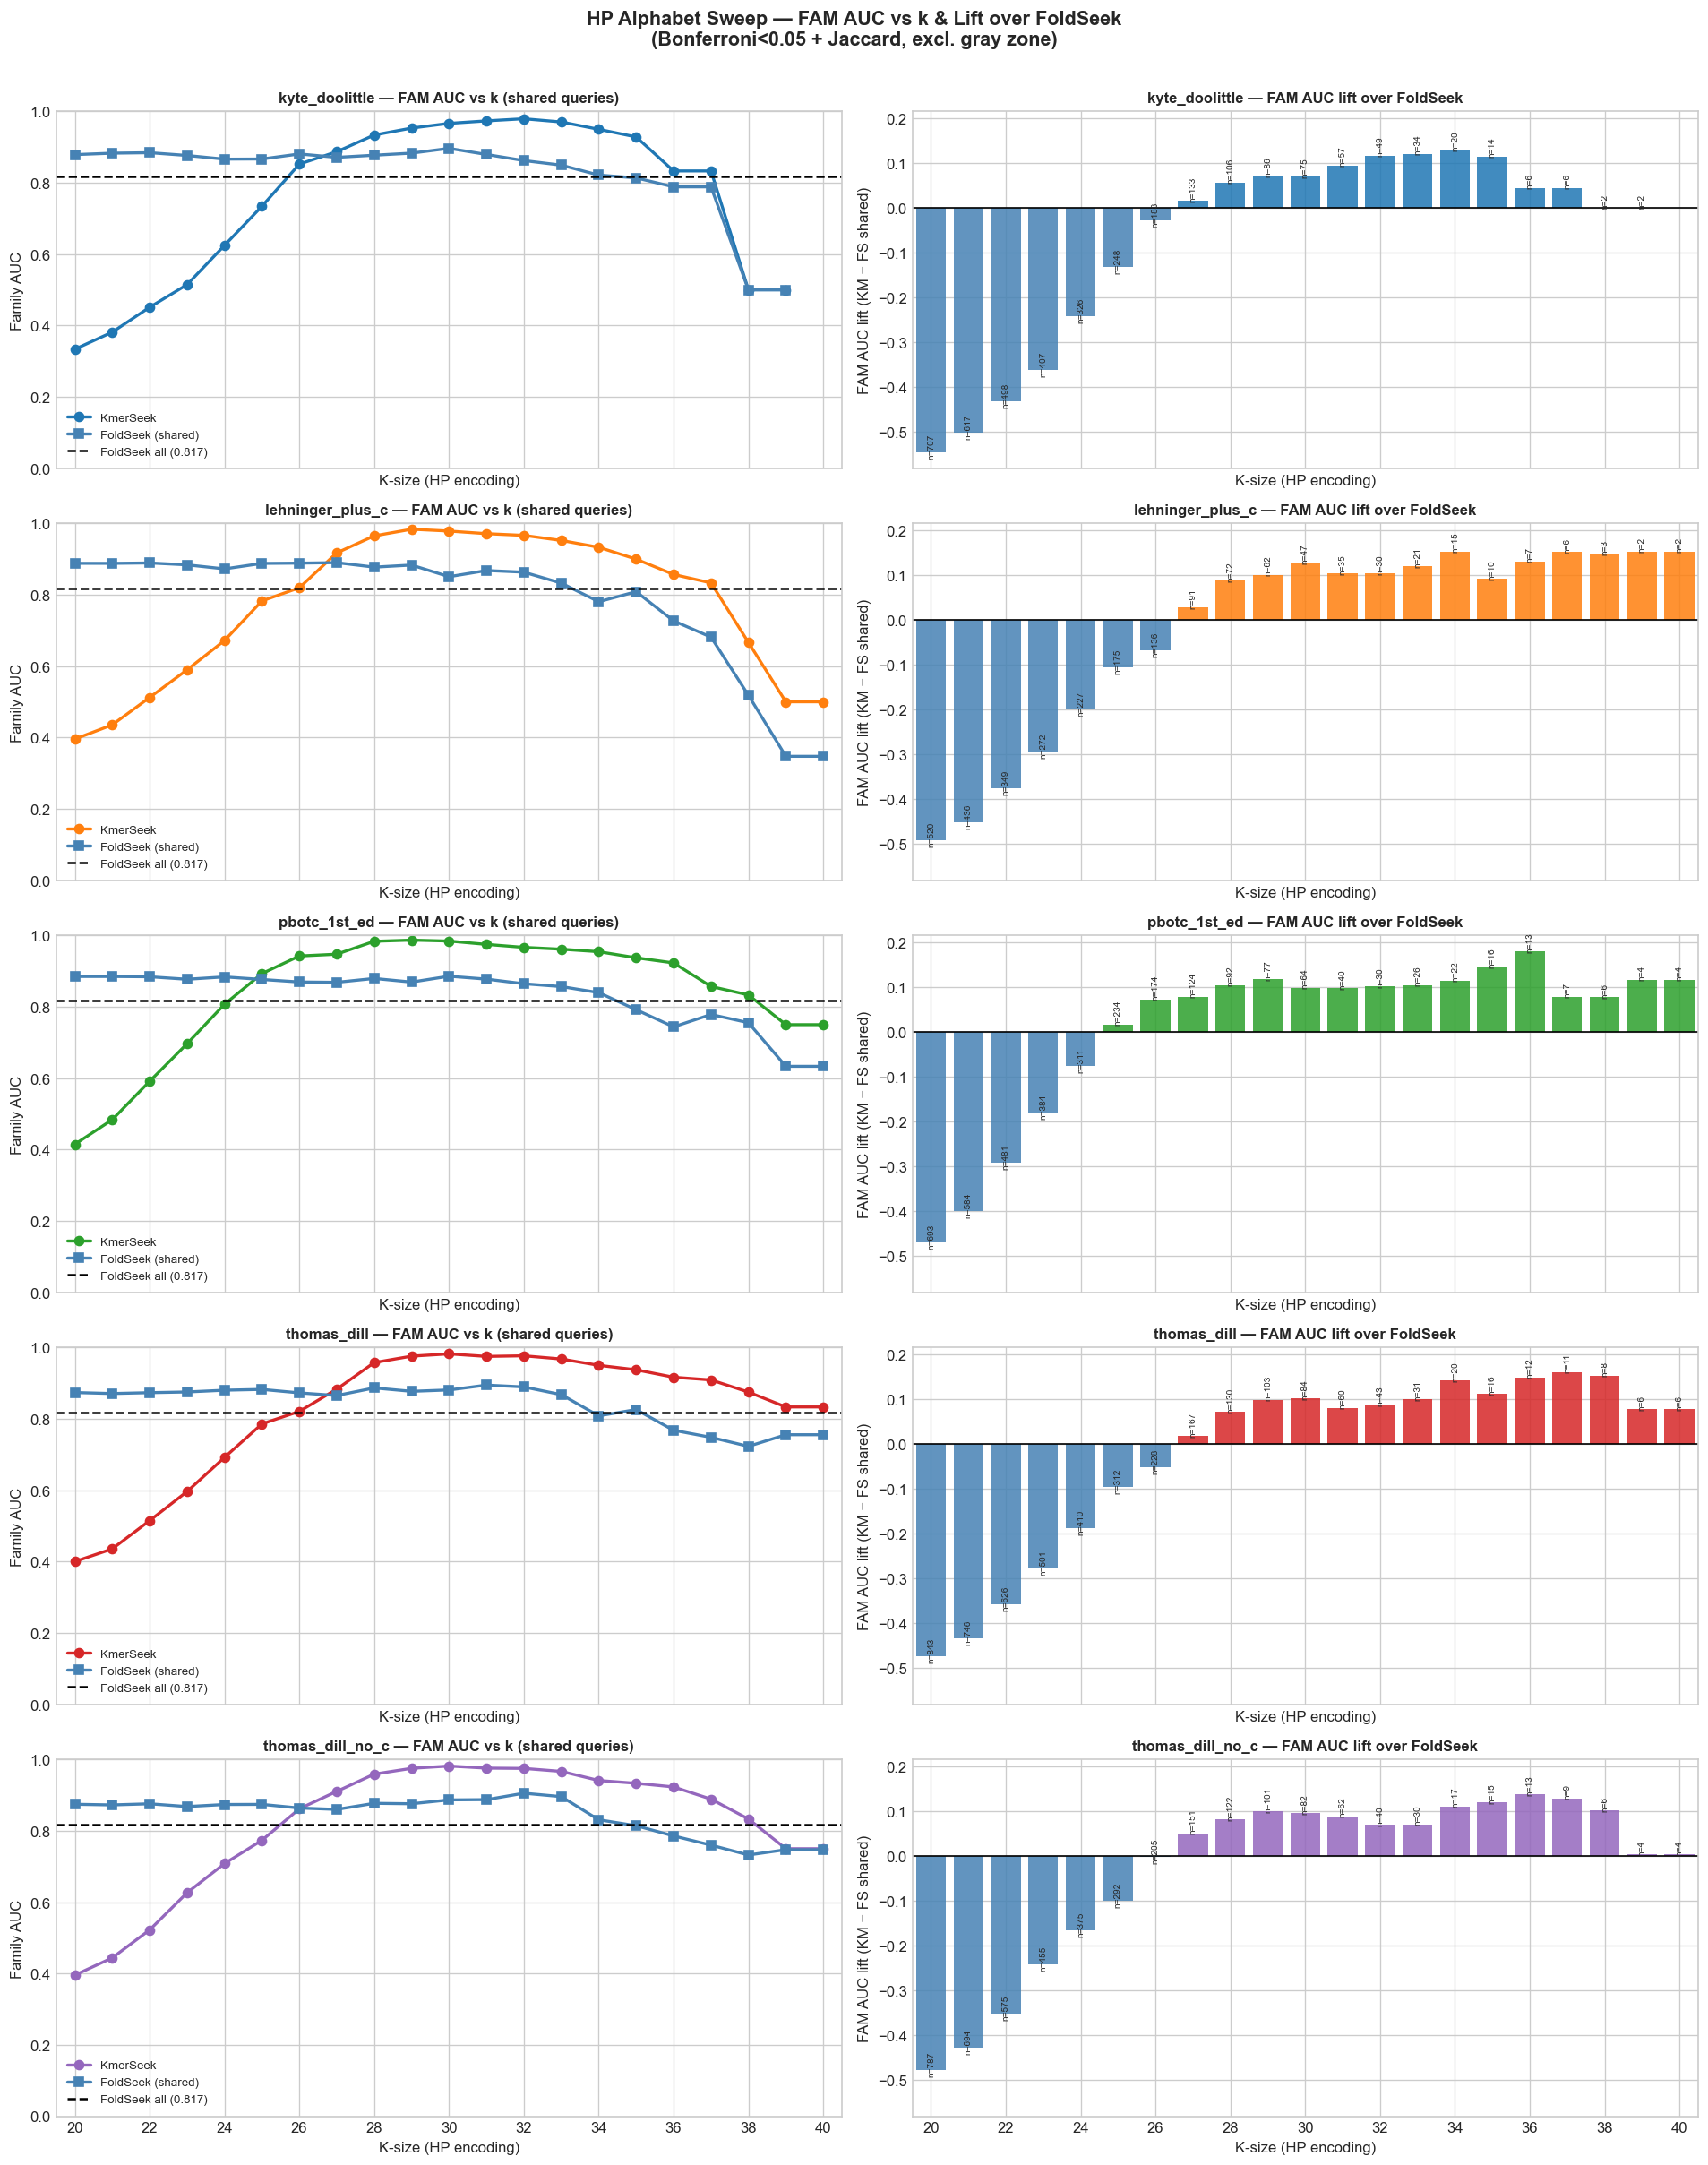

In [14]:
if lift_df.height == 0:
    print('No lift data to plot.')
else:
    # Only plot alphabets that have lift data
    labels_with_data = [lbl for lbl in NAMED_LABELS
                        if lift_df.filter(pl.col('label') == lbl).height > 0]
    n_named = len(labels_with_data)
    fig, axes = plt.subplots(n_named, 2, figsize=(16, 4 * n_named), sharex='col', sharey='col')
    if n_named == 1:
        axes = axes[np.newaxis, :]

    xlim = (KSIZES[0] - 0.5, KSIZES[-1] + 0.5)

    for row_i, label in enumerate(labels_with_data):
        sub = lift_df.filter(pl.col('label') == label).sort('ksize')
        ax_auc, ax_lift = axes[row_i]
        color = NAMED_COLORS[label]

        ks  = sub['ksize'].to_numpy()
        km  = sub['km_fam'].to_numpy()
        fs  = sub['fs_fam_shared'].to_numpy()
        lft = sub['lift'].to_numpy()
        n   = sub['n_cov'].to_numpy()

        # Left: AUC vs k
        ax_auc.plot(ks, km, 'o-', color=color, lw=2, ms=6, label='KmerSeek')
        ax_auc.plot(ks, fs, 's-', color='steelblue', lw=2, ms=6, label='FoldSeek (shared)')
        ax_auc.axhline(fs_fam, color='black', ls='--', lw=1.5, label=f'FoldSeek all ({fs_fam:.3f})')
        ax_auc.set_xlabel('K-size (HP encoding)', fontsize=10)
        ax_auc.set_ylabel('Family AUC', fontsize=10)
        ax_auc.set_title(f'{label.replace("hp_", "")} — FAM AUC vs k (shared queries)',
                         fontsize=10, fontweight='bold')
        ax_auc.legend(fontsize=8); ax_auc.set_ylim(0, 1)
        ax_auc.set_xlim(*xlim)
        ax_auc.xaxis.set_major_locator(plt.MultipleLocator(2))

        # Right: lift bar chart
        bar_colors = np.where(lft > 0, color, 'steelblue')
        ax_lift.bar(ks, lft, color=bar_colors, alpha=0.85)
        ax_lift.axhline(0, color='black', lw=1)
        ax_lift.set_xlabel('K-size (HP encoding)', fontsize=10)
        ax_lift.set_ylabel('FAM AUC lift (KM − FS shared)', fontsize=10)
        ax_lift.set_title(f'{label.replace("hp_", "")} — FAM AUC lift over FoldSeek',
                          fontsize=10, fontweight='bold')
        ax_lift.set_xlim(*xlim)
        ax_lift.xaxis.set_major_locator(plt.MultipleLocator(2))
        for xi, ki, li, ni in zip(range(len(ks)), ks, lft, n):
            ax_lift.text(ki, li + (0.003 if li >= 0 else -0.010),
                         f'n={ni}', ha='center', fontsize=6, rotation=90)

    plt.suptitle(
        f'HP Alphabet Sweep — FAM AUC vs k & Lift over FoldSeek\n'
        f'(Bonferroni<{BONF_THRESHOLD} + Jaccard, excl. gray zone)',
        fontsize=13, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.savefig(f'{FIG_PREFIX}_fam_auc_lift.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Sensitivity curves — each tool on its own queries

Plots the TEA-style sensitivity curve for FoldSeek, TEA, and KmerSeek (best: thomas_dill k=26), each evaluated **only on their own covered queries** (no common-query restriction). X-axis = fraction of that tool's queries ranked descending by sensitivity; Y-axis = family/superfamily/fold sensitivity.

KmerSeek (hp_thomas_dill k=26): 683 own covered queries


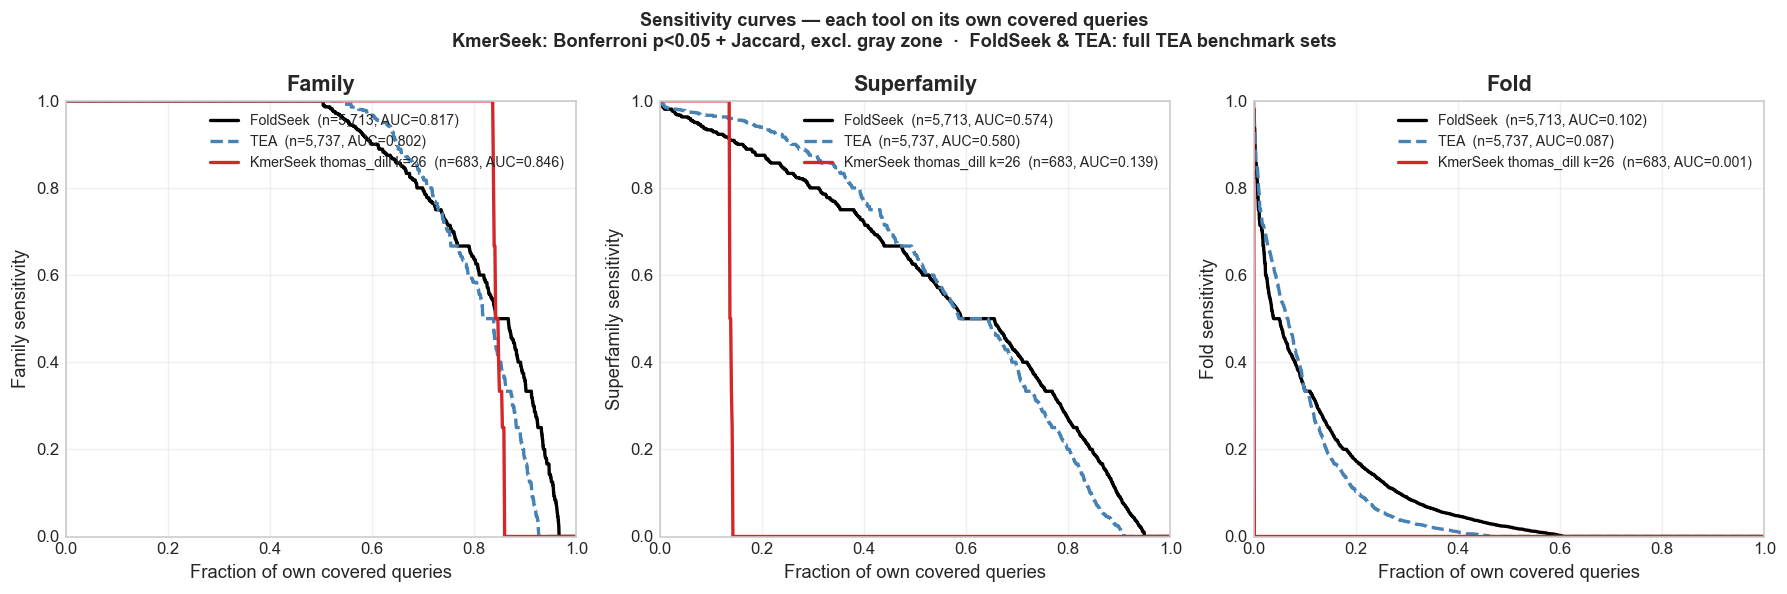

Saved: ../figures/075_roc_own_queries.png


In [15]:
# ── KmerSeek best: uses BEST_LABEL / BEST_K from notebook setup ───────────────
KM_LABEL = BEST_LABEL   # hp_thomas_dill
KM_K     = BEST_K       # 26

ev_km      = load_eval_alphabet(KM_LABEL, KM_K, columns=EVAL_USECOLS)
ev_km      = add_composite_scores_scope(ev_km)
ev_km      = recompute_bonferroni(ev_km)
ev_km_filt = ev_km.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
rocx_km    = eval_tsv_to_rocx(ev_km_filt, score_col='jaccard', ascending=False,
                               exclude_gray_zone=True)
n_km = rocx_km['NAME'].n_unique()
print(f'KmerSeek ({KM_LABEL} k={KM_K}): {n_km:,} own covered queries')

# ── Plot: 3 SCOP levels, each tool on its own queries ─────────────────────────
LEVELS   = [('FAM', 'Family'), ('SFAM', 'Superfamily'), ('FOLD', 'Fold')]
KM_COLOR = NAMED_COLORS[KM_LABEL]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (level, level_name) in zip(axes, LEVELS):
    fs_frac,  fs_sens,  fs_auc_own  = sensitivity_stats(foldseek, level)
    tea_frac, tea_sens, tea_auc_own = sensitivity_stats(tea_all,  level)
    km_frac,  km_sens,  km_auc_own  = sensitivity_stats(rocx_km,  level)

    n_fs  = foldseek['NAME'].n_unique()
    n_tea = tea_all['NAME'].n_unique()

    ax.plot(fs_frac,  fs_sens,  color='black',     lw=2,
            label=f'FoldSeek  (n={n_fs:,}, AUC={fs_auc_own:.3f})')
    ax.plot(tea_frac, tea_sens, color='steelblue', lw=2, ls='--',
            label=f'TEA  (n={n_tea:,}, AUC={tea_auc_own:.3f})')
    ax.plot(km_frac,  km_sens,  color=KM_COLOR,    lw=2,
            label=f'KmerSeek {KM_LABEL.replace("hp_", "")} k={KM_K}  (n={n_km:,}, AUC={km_auc_own:.3f})')

    ax.set_xlabel('Fraction of own covered queries', fontsize=11)
    ax.set_ylabel(f'{level_name} sensitivity', fontsize=11)
    ax.set_title(level_name, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Sensitivity curves — each tool on its own covered queries\n'
    f'KmerSeek: Bonferroni p<{BONF_THRESHOLD} + Jaccard, excl. gray zone  ·  '
    f'FoldSeek & TEA: full TEA benchmark sets',
    fontsize=11, fontweight='bold')
plt.tight_layout()
out_path = f'{FIG_PREFIX}_roc_own_queries.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')